# 기본환경 설정

In [1]:
import os, zipfile, urllib.request, math
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
# 하이퍼파라미터
seq_len     = 24       # LSTM 입력 길이(과거 24시간)
batch_size  = 32
hidden_dim  = 64
num_layers  = 3
dropout     = 0.3
lr          = 1e-4
epochs      = 30

In [4]:
# 특성/타깃 선택
feature_cols = ["T", "RH", "AH", "PT08.S5(O3)", "NO2(GT)", "NO2(GT)", "PT08.S3(NOx)"] # 입력에 쓸 컬럼 (온도, 상대습고, 절대습도)
target_col   = "T" # 다음 시점 예측할 컬럼

* UCI Air Quality 데이터 : 이탈리아의 한 도시 도로변(오염이 심한 지역)에 설치된 가스 멀티센서 장치에서 매 시각(hourly) 평균값을 수집한 시계열 데이터

In [5]:
# 데이터 경로/URL
DATA_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip"
DATA_DIR  = "data/data_airquality"
ZIP_PATH  = os.path.join(DATA_DIR, "AirQualityUCI.zip")
CSV_PATH  = os.path.join(DATA_DIR, "AirQualityUCI.csv")

In [6]:
# 장치 선택 — GPU가 있으면 GPU, 없으면 CPU
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

device(type='cuda')

# Data Loading

In [7]:
os.makedirs(DATA_DIR, exist_ok=True)

In [8]:
if not os.path.exists(CSV_PATH):
    print("[INFO] Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        with zf.open("AirQualityUCI.csv") as f, open(CSV_PATH, "wb") as out:
            out.write(f.read())
    print(f"[INFO] Saved: {CSV_PATH}")
else:
    print("[INFO] CSV already exists:", CSV_PATH)

[INFO] Downloading dataset...
[INFO] Saved: data/data_airquality/AirQualityUCI.csv


In [9]:
# UCI 파일은 세미콜론(;) 구분, 소수점 ,(comma), -200은 결측치 코드
df = pd.read_csv(
    CSV_PATH,
    sep=";",
    decimal=",",
    na_values=-200,
    dtype={"Date": "string", "Time": "string"},
    low_memory=False,
)

In [10]:
datetime = df["Date"].str.strip() + " " + df["Time"].str.strip()
df["datetime"] = pd.to_datetime(datetime, format="%d/%m/%Y %H.%M.%S")

In [11]:
df.drop(columns=["Date", "Time"], inplace=True)
df.sort_values("datetime", inplace=True)

# 전처리

In [13]:
# 전부 NaN인 컬럼 제거(파일 끝의 빈 컬럼 등)
df = df.dropna(axis=1, how="all")

In [14]:
# 결측치 처리(-200 -> NaN) 후 시계열 보간
df = df.replace(-200, np.nan).sort_values("datetime").reset_index(drop=True)
df = df.ffill().bfill() # 각 컬럼별로 앞/뒤 값 복사(fill) 방식

In [15]:
# 인덱스 설정
df = df.set_index("datetime")

* UCI Air Quality 데이터
    - Date (형식 DD/MM/YYYY)
    - Time (형식 HH.MM.SS)
    - CO(GT) – 기준 분석기로 측정한 CO 시평균 농도 (mg/m^3)
    - PT08.S1(CO) – 센서 응답(주 대상: CO)
    - NMHC(GT) – 기준 분석기 NMHC(비메탄 탄화수소) (µg/m^3)
    - C6H6(GT) – 기준 분석기 벤젠 (µg/m^3)
    - PT08.S2(NMHC) – 센서 응답(주 대상: NMHC)
    - NOx(GT) – 기준 분석기 NOx (ppb)
    - PT08.S3(NOx) – 센서 응답(주 대상: NOx)
    - NO2(GT) – 기준 분석기 NO2 (µg/m^3)
    - PT08.S4(NO2) – 센서 응답(주 대상: NO2)
    - PT08.S5(O3) – 센서 응답(주 대상: O3)
    - T – 온도 (°C)
    - RH – 상대습도 (%)
    - AH – 절대습도

In [17]:
# 사용 컬럼 미리 확인
df[feature_cols + [target_col]].head(3)

,T,RH,AH,PT08.S5(O3),NO2(GT),NO2(GT),PT08.S3(NOx),T
datetime,,,,,,,,
2004-03-10 18:00:00,13.6,48.9,0.7578,1268.0,113.0,113.0,1056.0,13.6
2004-03-10 19:00:00,13.3,47.7,0.7255,972.0,92.0,92.0,1174.0,13.3
2004-03-10 20:00:00,11.9,54.0,0.7502,1074.0,114.0,114.0,1140.0,11.9


# 학습 데이터 생성

In [18]:
# 다음 시점 예측(horizon=1) => 이전값을 예측값으로 사용하여 학습해서, 예측 모델을 만들기 위해 사용
horizon = 1
data = df[sorted(set(feature_cols + [target_col]))].copy()
data["target"] = data[target_col].shift(-horizon) #shift를 하면 타킷 값(해당 컬럼만)만 밑으로 내린다(+), 위로 올린다(-)
data = data.dropna().reset_index(drop=False)  # 끝부분 NaN 제거 (11.9가 위로 올라가서 NaN 발생)

In [19]:
data

,datetime,AH,NO2(GT),PT08.S3(NOx),PT08.S5(O3),RH,T,target
0,2004-03-10 18:00:00,0.7578,113.0,1056.0,1268.0,48.9,13.6,13.3
1,2004-03-10 19:00:00,0.7255,92.0,1174.0,972.0,47.7,13.3,11.9
2,2004-03-10 20:00:00,0.7502,114.0,1140.0,1074.0,54.0,11.9,11.0
3,2004-03-10 21:00:00,0.7867,122.0,1092.0,1203.0,60.0,11.0,11.2
4,2004-03-10 22:00:00,0.7888,116.0,1205.0,1110.0,59.6,11.2,11.2
...,...,...,...,...,...,...,...,...
9465,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5
9466,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5
9467,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5
9468,2005-04-04 14:00:00,0.5028,168.0,654.0,816.0,13.1,28.5,28.5


## 학습, 검증, 테스트 데이터 분리

In [20]:
N = len(data)
n_train = int(N * 0.7)
n_val   = int(N * 0.1)
n_test  = N - n_train - n_val
n_train, n_val, n_test

(6629, 947, 1894)

In [21]:
train_df = data.iloc[:n_train]
val_df   = data.iloc[n_train:n_train+n_val]
test_df  = data.iloc[n_train+n_val:]

In [22]:
X_train = train_df[feature_cols].values
X_val   = val_df[feature_cols].values
X_test  = test_df[feature_cols].values

In [23]:
y_train = train_df["target"].values.reshape(-1, 1)
y_val   = val_df["target"].values.reshape(-1, 1)
y_test  = test_df["target"].values.reshape(-1, 1)

## 표준화

In [24]:
# 표준화(훈련셋 기준)
x_scaler = StandardScaler().fit(X_train) #트레인 데이터로 알고리즘이 제작되, 실무에 사용하기 위해서, 트레인 데이터만 Scaler할 것.
y_scaler = StandardScaler().fit(y_train)

In [25]:
X_train_s = x_scaler.transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

In [26]:
y_train_s = y_scaler.transform(y_train)
y_val_s   = y_scaler.transform(y_val)
y_test_s  = y_scaler.transform(y_test)

In [27]:
X_train_s.shape, y_train_s.shape, X_val_s.shape, y_val_s.shape, X_test_s.shape, y_test_s.shape

((6629, 7), (6629, 1), (947, 7), (947, 1), (1894, 7), (1894, 1))

## Dataset 생성

In [51]:
class SeqDataset(Dataset):
    """ (seq_len, features) 윈도우 -> 다음 시점 타깃 """
    def __init__(self, X, y, seq_len=24):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.idxs = [(i-seq_len, i) for i in range(seq_len, len(X))] #9469개 데이터에서 어떤 데이터를 얼마나 가져올지, 24개의 데이터가 가져오게 생성

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        s, e = self.idxs[i]
        x = self.X[s:e]         # (L, F)
        y = self.y[e]           # (1,)
        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

In [52]:
train_ds = SeqDataset(X_train_s, y_train_s, seq_len=seq_len)
val_ds   = SeqDataset(X_val_s,   y_val_s,   seq_len=seq_len)
test_ds  = SeqDataset(X_test_s,  y_test_s,  seq_len=seq_len)

In [53]:
len(train_ds), len(val_ds), len(test_ds)

(6605, 923, 1870)

## Dataloader 생성

In [54]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

In [55]:
next(iter(train_loader))[0].shape  # (batch, seq_len, features)

torch.Size([32, 24, 7])

# 모델 생성

In [56]:
pip install torchinfo

In [57]:
from torchinfo import summary

In [58]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        """
        * num_layers 2를 tensorflow로 구현
        inputs = layers.Input(shape=(seq_len, input_size))
        x = layers.LSTM(hidden_size, return_sequences=True, dropout=0.0, recurrent_dropout=0.0)(inputs)
        x = layers.LSTM(hidden_size, return_sequences=True, dropout=0.0, recurrent_dropout=0.0)(x)
        """
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim, #LSTM의 가운데 사이즈
            num_layers=num_layers, #3번을 회전?
            dropout=dropout,
            batch_first=True # True이면 입력/출력의 형태가 (batch, seq_len, feature), False(기본값)이면 (seq_len, batch, feature)
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, L, F)
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # 마지막 타임스텝
        yhat = self.fc(last)          # (B, 1)
        return yhat

In [59]:
model = LSTMRegressor(
    input_dim=len(feature_cols),
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout
).to(device)

In [60]:
model

LSTMRegressor(
  (lstm): LSTM(7, 64, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [61]:
summary(model, input_size=(1, seq_len, len(feature_cols)))

Layer (type:depth-idx)                   Output Shape              Param #
LSTMRegressor                            [1, 1]                    --
├─LSTM: 1-1                              [1, 24, 64]               85,248
├─Linear: 1-2                            [1, 1]                    65
Total params: 85,313
Trainable params: 85,313
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.34
Estimated Total Size (MB): 0.35

In [62]:
loss_fn = nn.MSELoss() #에러 평균 계산
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# 학습

In [63]:
best_val = float("inf")
best_state = None

In [64]:
for epoch in range(1, epochs + 1):
    # train
    model.train()
    train_loss_sum, n_train_samples = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)
        n_train_samples += xb.size(0)
    train_mse = train_loss_sum / n_train_samples

    # val
    model.eval()
    with torch.no_grad():
        val_loss_sum, n_val_samples = 0.0, 0
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            val_loss_sum += loss.item() * xb.size(0)
            n_val_samples += xb.size(0)
        val_mse = val_loss_sum / n_val_samples

    if val_mse < best_val:
        best_val = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"[{epoch:03d}] train_mse={train_mse:.5f}  val_mse={val_mse:.5f}")

# 베스트 가중치 복원
if best_state is not None:
    model.load_state_dict(best_state)

[001] train_mse=0.70295  val_mse=0.25729
[002] train_mse=0.39516  val_mse=0.19350
[003] train_mse=0.31446  val_mse=0.12445
[004] train_mse=0.14340  val_mse=0.08772
[005] train_mse=0.10703  val_mse=0.07515
[006] train_mse=0.09579  val_mse=0.07019
[007] train_mse=0.08860  val_mse=0.07279
[008] train_mse=0.08482  val_mse=0.06197
[009] train_mse=0.08405  val_mse=0.06683
[010] train_mse=0.07890  val_mse=0.05489
[011] train_mse=0.07878  val_mse=0.05886
[012] train_mse=0.07820  val_mse=0.05278
[013] train_mse=0.07434  val_mse=0.05707
[014] train_mse=0.07333  val_mse=0.05125
[015] train_mse=0.07367  val_mse=0.06616
[016] train_mse=0.07054  val_mse=0.04607
[017] train_mse=0.07092  val_mse=0.05600
[018] train_mse=0.06942  val_mse=0.05228
[019] train_mse=0.06772  val_mse=0.05030
[020] train_mse=0.06671  val_mse=0.04710
[021] train_mse=0.06682  val_mse=0.04489
[022] train_mse=0.06517  val_mse=0.04473
[023] train_mse=0.06413  val_mse=0.04428
[024] train_mse=0.06427  val_mse=0.04471
[025] train_mse=

# 테스트 데이터 검증

In [65]:
model.eval()
preds_s, trues_s = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        preds_s.append(pred)
        trues_s.append(yb.numpy())

In [66]:
preds_s = np.vstack(preds_s)
trues_s = np.vstack(trues_s)

In [67]:
# 역변환(표준화 복원)
preds = y_scaler.inverse_transform(preds_s)
trues = y_scaler.inverse_transform(trues_s)

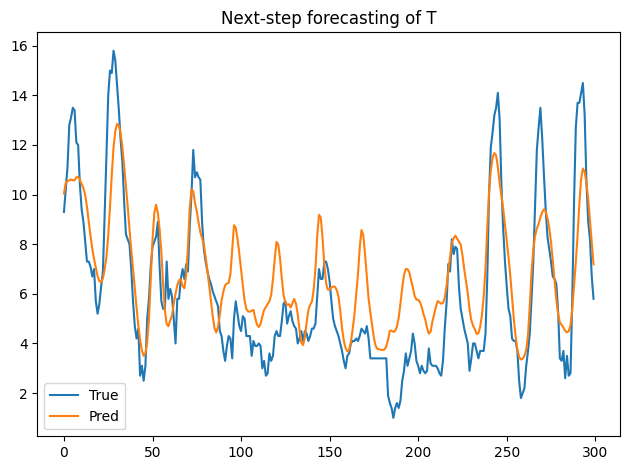

In [68]:
# 앞부분 200개만 그려보기
n_show = min(300, len(preds))
plt.figure()
plt.plot(trues[:n_show], label="True")
plt.plot(preds[:n_show], label="Pred")
plt.title(f"Next-step forecasting of {target_col}")
plt.legend()
plt.tight_layout()
plt.show()

# 예측

In [ ]:
# 신규데이터
idx = -20
df_part = test_df.iloc[idx-24:idx][feature_cols]
part_next = df.iloc[idx+1][feature_cols]
part_next

In [ ]:
def predict(data):
    data_tensor = torch.from_numpy(data).unsqueeze(0).to(device, dtype=torch.float32)
    with torch.no_grad():
        pred_next_s = model(data_tensor).cpu().numpy()
    return y_scaler.inverse_transform(pred_next_s.reshape(-1, 1)).item()

In [ ]:
predict(df_part.values)